# Лабораторна 12 - Автоенкодери на практиці


**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 12  
**Тема лабораторної:** Автоенкодери на практиці

## Цілі лабораторної

- Побудова Autoencoder та DenoisingAutoencoder (6 завдань) 
- Навчання та реконструкція на Fashion-MNIST 
- t-SNE візуалізація латентного простору 
- Інтерполяція в латентному просторі 
- Знешумлюючий автоенкодер: порівняння з AE 
- Кластеризація та узагальнювальна здатність 

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import warnings
warnings.filterwarnings('ignore')

import torch
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Jupyter display
%matplotlib inline

# Reproducibility
SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE as COLORS
setup_plot_style()

import autoencoder_student as ae
importlib.reload(ae)

<module 'autoencoder_solution' from 'c:\\Users\\yuriy.muzychuk\\Documents\\Edu\\ML\\machine-learning-part-2\\course\\week-12\\autoencoder_solution.py'>

## Завантаження Fashion-MNIST

**Fashion-MNIST** (Xiao et al., 2017) — «складніший» замінник MNIST:
60 000 тренувальних та 10 000 тестових зображень одягу та взуття
розміром 28×28 = **784 пікселі** у 10 класах.

| Клас | Назва | Клас | Назва |
|------|-------|------|-------|
| 0 | T-shirt/top | 5 | Sandal |
| 1 | Trouser | 6 | Shirt |
| 2 | Pullover | 7 | Sneaker |
| 3 | Dress | 8 | Bag |
| 4 | Coat | 9 | Ankle boot |

Для швидкості навчання ми використовуємо збалансовану підвибірку:
**600 зображень на клас** (6 000 всього), розбиту 80/20 на train/test.

In [3]:
# Load Fashion-MNIST via torchvision (downloads ~30 MB once, then cached)
import torchvision

fmnist_tr = torchvision.datasets.FashionMNIST('./data', train=True,  download=True)
fmnist_te = torchvision.datasets.FashionMNIST('./data', train=False, download=True)

X_raw = np.concatenate([
    fmnist_tr.data.numpy().reshape(-1, 784),
    fmnist_te.data.numpy().reshape(-1, 784),
]).astype(np.float32) / 255.0

y_raw = np.concatenate([
    fmnist_tr.targets.numpy(),
    fmnist_te.targets.numpy(),
])

# Balanced subsample: 600 per class -> 6 000 total
rng = np.random.RandomState(SEED)
idx = []
for c in range(10):
    class_idx = np.where(y_raw == c)[0]
    idx.extend(rng.choice(class_idx, size=600, replace=False))
idx   = np.array(idx)
X_sub = X_raw[idx]
y_sub = y_raw[idx]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=SEED
)

print(f'Full dataset  : {X_raw.shape}')
print(f'Subsample     : {X_sub.shape}')
print(f'Train split   : {X_tr.shape}')
print(f'Test  split   : {X_te.shape}')
print(f'Pixel range   : [{X_sub.min():.2f}, {X_sub.max():.2f}]')

100%|██████████| 26.4M/26.4M [00:00<00:00, 46.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 2.06MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 16.3MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


Full dataset  : (70000, 784)
Subsample     : (6000, 784)
Train split   : (4800, 784)
Test  split   : (1200, 784)
Pixel range   : [0.00, 1.00]


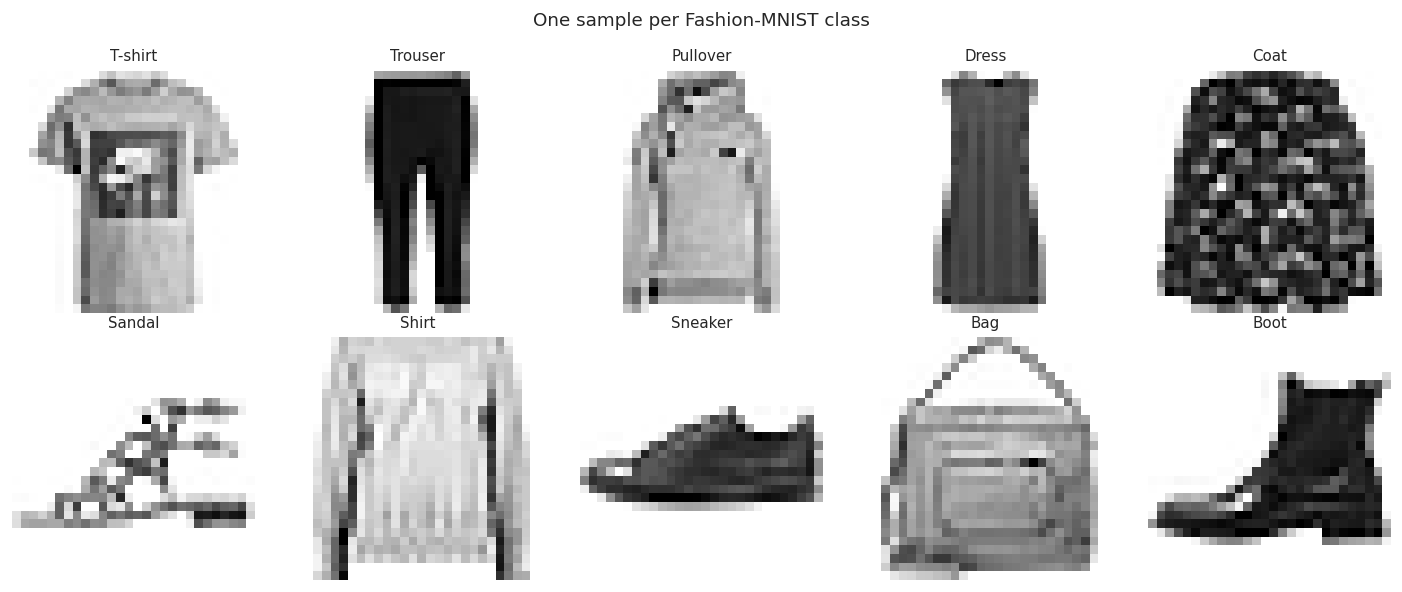

In [5]:
# Visualise one sample per class
CLASS_NAMES = {
    0: 'T-shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress',  4: 'Coat',
    5: 'Sandal',  6: 'Shirt',   7: 'Sneaker',  8: 'Bag',    9: 'Boot',
}

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c, ax in zip(range(10), axes.flat):
    sample = X_sub[y_sub == c][0].reshape(28, 28)
    ax.imshow(sample, cmap='gray_r')
    ax.set_title(CLASS_NAMES[c], fontsize=9)
    ax.axis('off')
plt.suptitle('One sample per Fashion-MNIST class', fontsize=11)
plt.tight_layout()
plt.show()

---
## 1. Побудова Autoencoder та DenoisingAutoencoder

Архітектура та інтерфейс (`encode`, `decode`, `forward`) **ідентичні**
до тих, що показані на лекції. Різниця лише
в розмірах: тепер вхід **784-D** замість 64-D.

```
Encoder:  x(784) → Linear(784→256) → ReLU → Linear(256→16) → ReLU → z(16)
Decoder:  z(16)  → Linear(16→256)  → ReLU → Linear(256→784)→ Sigmoid → x̂(784)
```

**DenoisingAutoencoder** наслідується від `Autoencoder` і відрізняється
лише методом `forward`: під час навчання він додає гаусовий шум до $x$
перед кодуванням.

| # | Метод / функція | Що зробити |
|---|----------------|------------|
| **TODO 1** | `Encoder.forward` | `h = ReLU(fc1(x))`, `z = ReLU(fc2(h))`, return `z` |
| **TODO 2** | `Decoder.forward` | `h = ReLU(fc1(z))`, `x̂ = Sigmoid(fc2(h))`, return `x̂` |
| **TODO 3** | `Autoencoder.encode` | `return self.encoder(x)` |
| **TODO 4** | `Autoencoder.forward` | encode → decode, return `x̂` |
| **TODO 5** | `DenoisingAutoencoder.forward` | якщо `self.training`: додати шум, clamp; encode → decode |
| **TODO 6** | `train_autoencoder` | DataLoader → MSE → Adam (той самий цикл що на лекції) |

In [6]:
INPUT_DIM  = 784
HIDDEN_DIM = 256
LATENT_DIM = 16

model = ae.Autoencoder(
    input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM
)

# Shape sanity-check
x_dummy = torch.zeros(4, INPUT_DIM)
z_dummy = model.encode(x_dummy)
x_hat   = model(x_dummy)

print(f'Input shape    : {tuple(x_dummy.shape)}')
print(f'Latent z shape : {tuple(z_dummy.shape)}  (expected (4, 16))')
print(f'Output shape   : {tuple(x_hat.shape)}  (expected (4, 784))')
print(f'Output range   : [{x_hat.min().item():.3f}, {x_hat.max().item():.3f}]  (expected [0,1])')

# Also verify DenoisingAutoencoder
dae = ae.DenoisingAutoencoder(
    input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM, noise_std=0.2
)
dae.train()  # noise should be added in training mode
dae_out_train = dae(x_dummy)
dae.eval()   # no noise in eval mode
dae_out_eval  = dae(x_dummy)

print(f'\nDAE train output shape : {tuple(dae_out_train.shape)}')
print(f'DAE eval  output shape : {tuple(dae_out_eval.shape)}')

n_params = sum(p.numel() for p in model.parameters())
print(f'\nAutoencoder parameters : {n_params:,}')

Input shape    : (4, 784)
Latent z shape : (4, 16)  (expected (4, 16))
Output shape   : (4, 784)  (expected (4, 784))
Output range   : [0.447, 0.554]  (expected [0,1])

DAE train output shape : (4, 784)
DAE eval  output shape : (4, 784)

Autoencoder parameters : 410,912


---
## 2. Навчання та реконструкція

Навчаємо автоенкодер **100 епох** на 4 800 тренувальних зображеннях.
Fashion-MNIST складніший за `digits`: детальна текстура тканин не вкладається
у 16 вимірів — очікуйте дещо розмиті реконструкції.


> Навчання займає ~30–60 секунд на CPU.

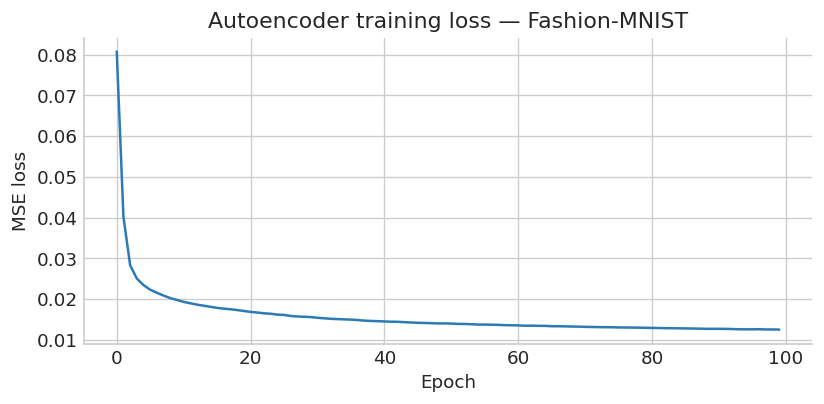

Initial loss : 0.0807    Final loss : 0.0125


In [7]:
torch.manual_seed(SEED)
model = ae.Autoencoder(
    input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM
)
losses = ae.train_autoencoder(
    model, X_tr, n_epochs=100, lr=1e-3, batch_size=64, seed=SEED
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(losses, color='#2C7BB6', lw=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('Autoencoder training loss — Fashion-MNIST')
plt.tight_layout()
plt.show()
print(f'Initial loss : {losses[0]:.4f}    Final loss : {losses[-1]:.4f}')

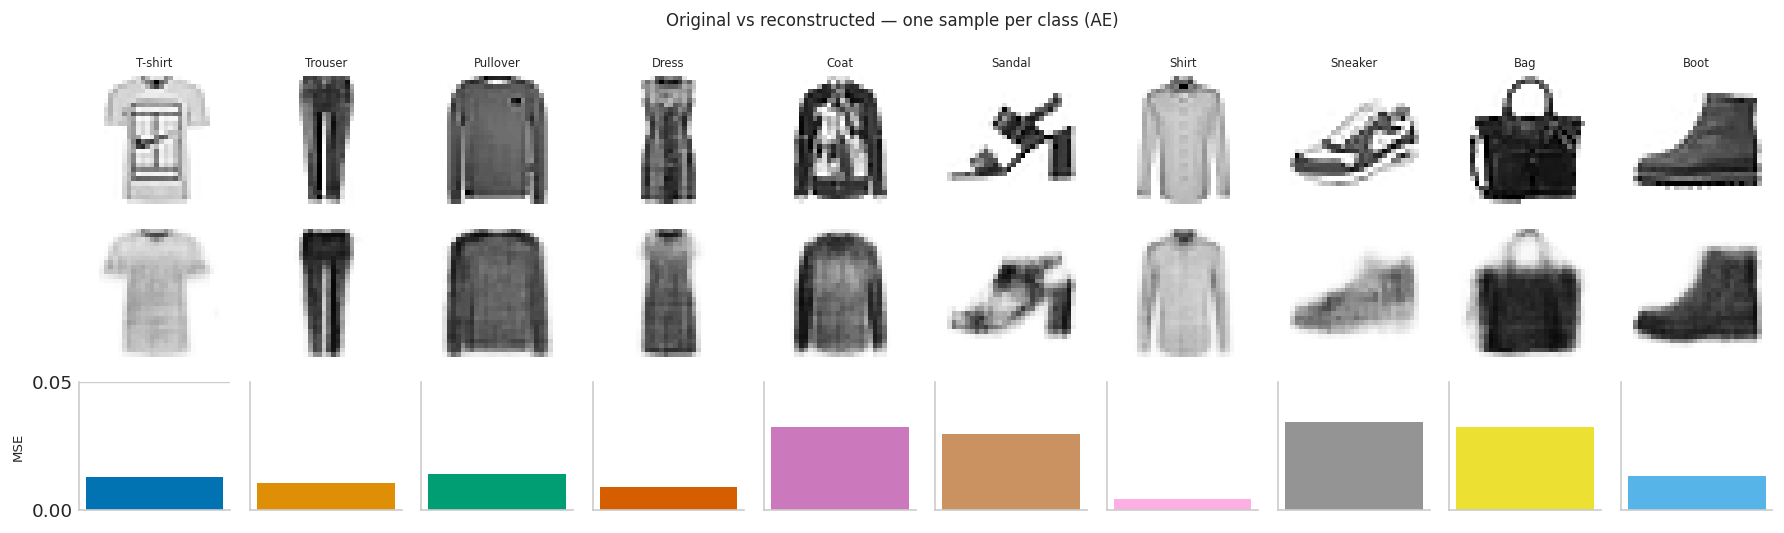

In [8]:
# Show original vs reconstructed for 2 samples per class
model.eval()
with torch.no_grad():
    X_hat_te = model(torch.tensor(X_te, dtype=torch.float32)).numpy()

n_cols = 10
fig, axes = plt.subplots(3, n_cols, figsize=(15, 4.5))

for col, c in enumerate(range(10)):
    i = np.where(y_te == c)[0][0]   # first test sample of this class
    axes[0, col].imshow(X_te[i].reshape(28, 28),    cmap='gray_r', vmin=0, vmax=1)
    axes[1, col].imshow(X_hat_te[i].reshape(28, 28), cmap='gray_r', vmin=0, vmax=1)
    err = np.mean((X_te[i] - X_hat_te[i]) ** 2)
    axes[2, col].bar([0], [err], color=COLORS[c])
    axes[2, col].set_ylim(0, 0.05)
    axes[2, col].set_xticks([])
    axes[2, col].set_yticks([])
    axes[0, col].set_title(CLASS_NAMES[c], fontsize=7)
    for row in range(2):
        axes[row, col].axis('off')

axes[0, 0].set_ylabel('Original',   fontsize=8)
axes[1, 0].set_ylabel('Reconstr.',  fontsize=8)
axes[2, 0].set_ylabel('MSE',        fontsize=8)
axes[2, 0].set_yticks([0, 0.05])
plt.suptitle('Original vs reconstructed — one sample per class (AE)', fontsize=10)
plt.tight_layout()
plt.show()

#### Що ми бачимо

Форма і колір одягу збережені, але деталі (текстура, ґудзики) розмиті:
16-вимірний код не може зберегти кожен піксель 784-вимірного зображення.
Деякі класи відтворюються гірше: **Coat** і **Pullover**, **Sandal** і **Sneaker** мають
схожі силуети, тому декодер плутає їх представлення.


На лекції ми бачили, що PCA з тією ж кількістю компонент (16) дає
вищу MSE реконструкції — автоенкодер ефективніший завдяки нелінійності.
Але лінійний зонд на PCA-компонентах міг давати кращу *класову* точність:
це підтвердимо в Part 5.

---
## 3. t-SNE візуалізація латентного простору

На лекції латентний простір `digits` візуалізувався за допомогою **PCA**
(лінійна проекція). Тут ми застосуємо **t-SNE** до кодів $z$ Fashion-MNIST,
що дає змогу побачити нелінійну структуру — кластери та сусідства,
приховані від лінійних методів.

Порівняємо три проекції в 2D:

| Метод | Вхід | Очікування |
|-------|------|------------|
| t-SNE на сирих пікселях (784D) | $x$ | Частково кластеризовано |
| t-SNE на латентних кодах (16D) | $z = f(x)$ | Кращі кластери після стиснення |
| PCA на латентних кодах | $z$ | Лінійна проекція для порівняння |

In [9]:
# Encode the full subsample (6000 images)
model.eval()
with torch.no_grad():
    Z_full = model.encode(
        torch.tensor(X_sub, dtype=torch.float32)
    ).numpy()   # shape (6000, 16)

print(f'Latent code matrix : {Z_full.shape}')

Latent code matrix : (6000, 16)


In [10]:
# t-SNE on raw pixels (subsample to 2000 for speed)
rng2   = np.random.RandomState(SEED)
idx2k  = rng2.choice(len(X_sub), size=2000, replace=False)
X_2k   = X_sub[idx2k]
Z_2k   = Z_full[idx2k]
y_2k   = y_sub[idx2k]

tsne_kw = dict(n_components=2, perplexity=30,
               learning_rate='auto', init='pca', random_state=SEED)

print('Computing t-SNE on raw pixels (2000 samples)...')
Y_raw  = TSNE(**tsne_kw).fit_transform(StandardScaler().fit_transform(X_2k))

print('Computing t-SNE on latent codes (2000 samples)...')
Y_lat  = TSNE(**tsne_kw).fit_transform(StandardScaler().fit_transform(Z_2k))

print('Done.')

Computing t-SNE on raw pixels (2000 samples)...
Computing t-SNE on latent codes (2000 samples)...
Done.


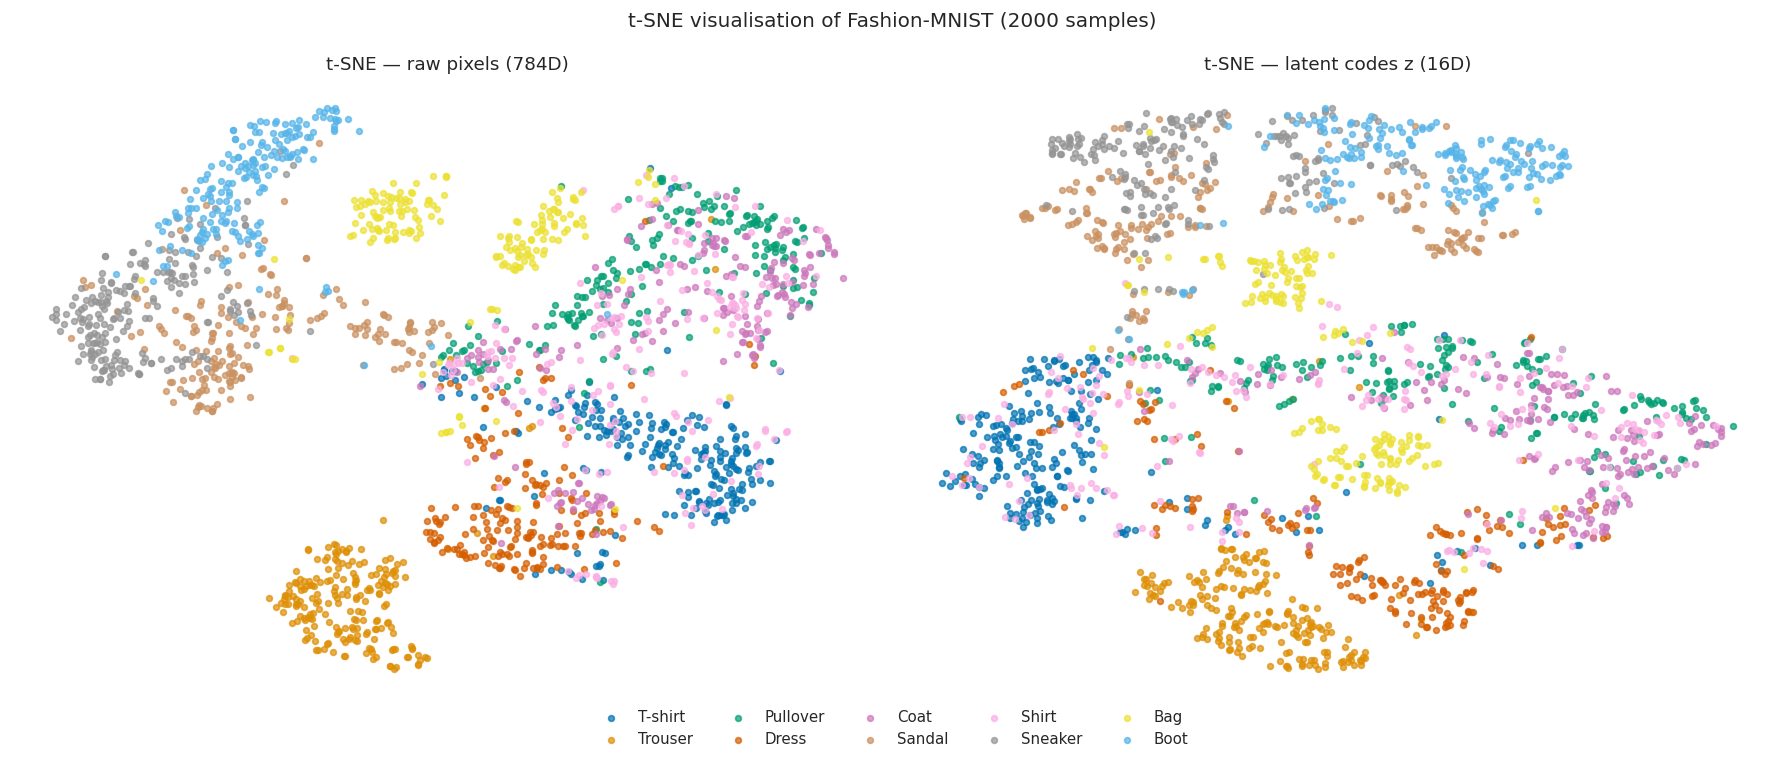

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, Y, title in [
    (axes[0], Y_raw, 't-SNE — raw pixels (784D)'),
    (axes[1], Y_lat, 't-SNE — latent codes z (16D)'),
]:
    for c, col in zip(range(10), COLORS):
        mask = y_2k == c
        ax.scatter(Y[mask, 0], Y[mask, 1],
                   color=col, label=CLASS_NAMES[c], s=12, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=5, loc='lower center',
           bbox_to_anchor=(0.5, -0.06), fontsize=9)
plt.suptitle('t-SNE visualisation of Fashion-MNIST (2000 samples)', fontsize=12)
plt.tight_layout()
plt.show()

#### Що ми бачимо

**t-SNE на сирих пікселях (784D):** деякі класи розділяються вже на рівні
пікселів. **Trouser** утворює чіткий ізольований кластер внизу зліва,
**Bag** відокремлений вгорі праворуч. Взуття (Sandal, Sneaker, Boot) тяжіє
до спільної зони. Натомість весь верхній одяг — T-shirt, Pullover, Coat,
Shirt, Dress — зливається в одну велику хмару в центрі: їхні піксельні
текстури надто схожі для лінійного сусідства t-SNE.

**t-SNE на латентних кодах $z$ (16D):** структура зберігається, але кластери
більш розпорошені і переплетені. Trouser і Bag залишаються відносно
відокремленими, однак верхній одяг стає ще важчим для розрізнення.
Загальне розділення **не покращилось** порівняно з пікселями.

Це прямо підтверджує спостереження лекції: автоенкодер,
оптимізований під MSE реконструкції, **не оптимізує** дискримінативність
латентного простору. Він зберігає форму силуету (тому Trouser і Bag
лишаються відокремленими), але не розводить семантично схожі категорії
одягу, бо це не вимагається функцією втрат.

---
## 4. Інтерполяція в латентному просторі

Якщо автоенкодер навчив **гладкий** латентний простір, лінійна
інтерполяція між двома кодами $z_A$ і $z_B$:

$$z_t = (1-t)\,z_A + t\,z_B, \quad t \in [0, 1]$$

декодується у плавний перехід між двома зображеннями.
Це неможливо в просторі сирих пікселів: піксельна інтерполяція
просто змішує кольори, а не форму.

Ми побудуємо **3 інтерполяційні доріжки** між різними класами
і подивимось, чи виникають реалістичні проміжні форми.

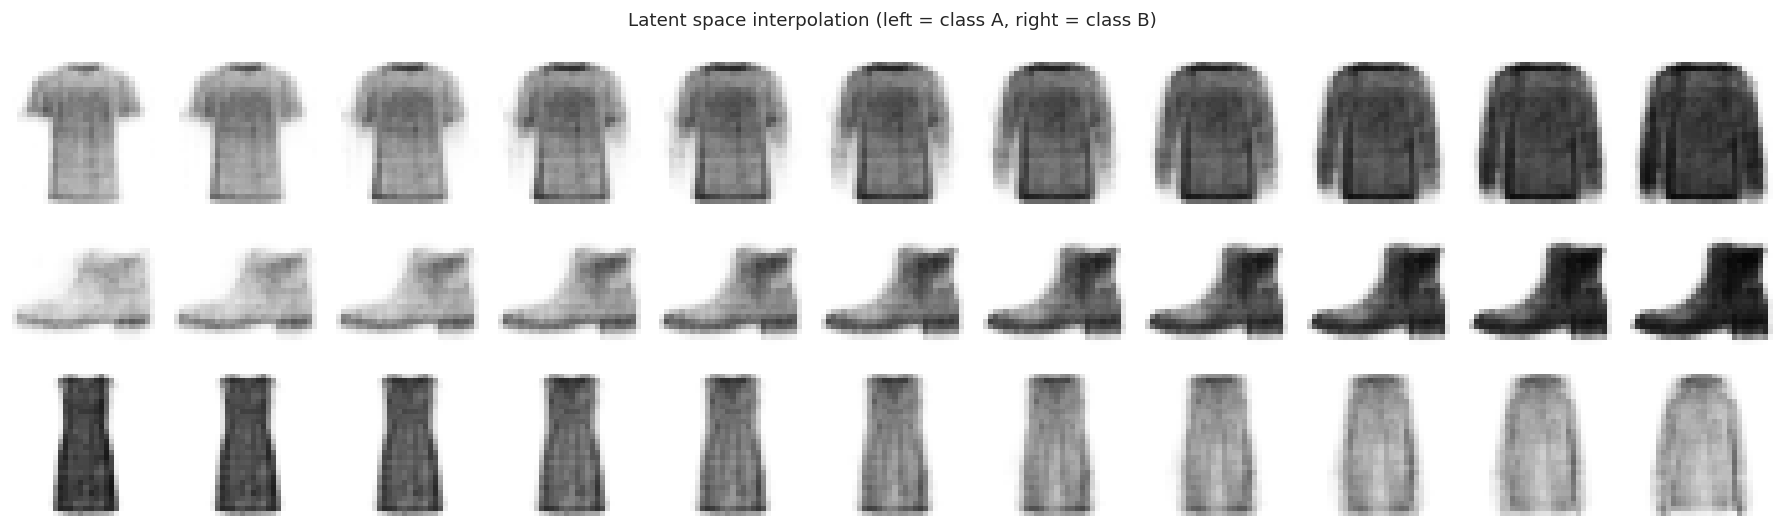

In [12]:
def interpolate(model, x_a, x_b, n_steps=9):
    """Encode x_a and x_b, interpolate n_steps times in latent space,
    decode each point. Returns array of shape (n_steps+2, input_dim)."""
    model.eval()
    with torch.no_grad():
        z_a = model.encode(torch.tensor(x_a, dtype=torch.float32).unsqueeze(0))
        z_b = model.encode(torch.tensor(x_b, dtype=torch.float32).unsqueeze(0))
        ts  = torch.linspace(0, 1, n_steps + 2)   # includes endpoints
        frames = []
        for t in ts:
            z_t    = (1 - t) * z_a + t * z_b
            x_hat  = model.decode(z_t)
            frames.append(x_hat.squeeze(0).numpy())
    return np.stack(frames)   # (n_steps+2, input_dim)


# Three interpolation pairs: semantically interesting transitions
pairs = [
    (0, 4, 'T-shirt → Coat'),
    (5, 9, 'Sandal → Boot'),
    (3, 2, 'Dress → Pullover'),
]

fig, axes = plt.subplots(3, 11, figsize=(15, 4.5))
for row, (cls_a, cls_b, title) in enumerate(pairs):
    x_a = X_sub[y_sub == cls_a][0]
    x_b = X_sub[y_sub == cls_b][0]
    frames = interpolate(model, x_a, x_b, n_steps=9)

    for col, img in enumerate(frames):
        axes[row, col].imshow(img.reshape(28, 28), cmap='gray_r', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(title, fontsize=8, rotation=90, labelpad=4)

plt.suptitle('Latent space interpolation (left = class A, right = class B)',
             fontsize=11)
plt.tight_layout()
plt.show()

#### Що ми бачимо

Якщо латентний простір гладкий, проміжні зображення виглядають як
логічний перехід між класами: наприклад, T-shirt поступово набуває
форму Coat — рукави видовжуються, силует розширюється.

Якщо ж проміжні кадри виглядають «розмитим коктейлем» без структури —
це свідчить, що кластери двох класів **не з'єднані** в латентному просторі:
між ними є область, де декодер ніколи не навчався.

---
## 5. Знешумлюючий автоенкодер: порівняння з AE

На лекції показано концепцію **Denoising AE (DAE)**:
модель навчається відновлювати *чисте* зображення із *зашумленого* входу.

Навчальний цикл **ідентичний** до звичайного AE: `train_autoencoder` додає
шум внутрішньо під час прямого проходу, MSE обчислюється відносно чистого $x$.

Тут ми порівняємо:
1. **Якість реконструкції** при різних рівнях зовнішнього шуму.
2. **Лінійний зонд** на латентних кодах AE vs DAE (чи підтверджується
   спостереження з лекції на новому датасеті?).

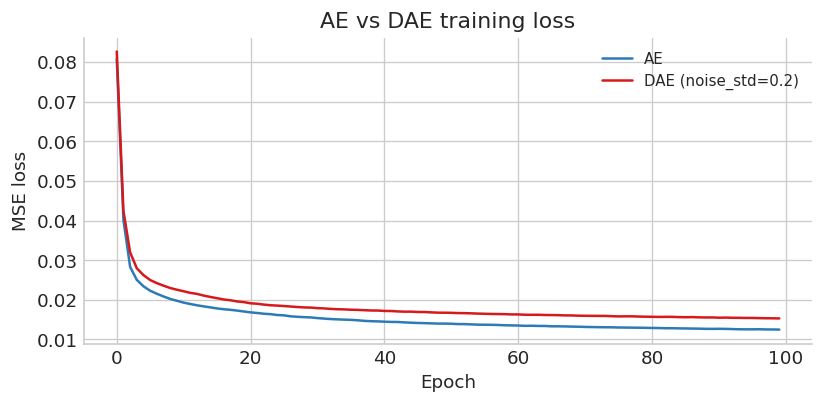

AE  final loss : 0.0125
DAE final loss : 0.0153


In [13]:
# Train DAE (same hyperparameters as AE for a fair comparison)
torch.manual_seed(SEED)
dae_model = ae.DenoisingAutoencoder(
    input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM, noise_std=0.2,
)
losses_dae = ae.train_autoencoder(
    dae_model, X_tr, n_epochs=100, lr=1e-3, batch_size=64, seed=SEED
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(losses,     color='#2C7BB6', lw=1.5, label='AE')
ax.plot(losses_dae, color='#D7191C', lw=1.5, label='DAE (noise_std=0.2)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('AE vs DAE training loss')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'AE  final loss : {losses[-1]:.4f}')
print(f'DAE final loss : {losses_dae[-1]:.4f}')

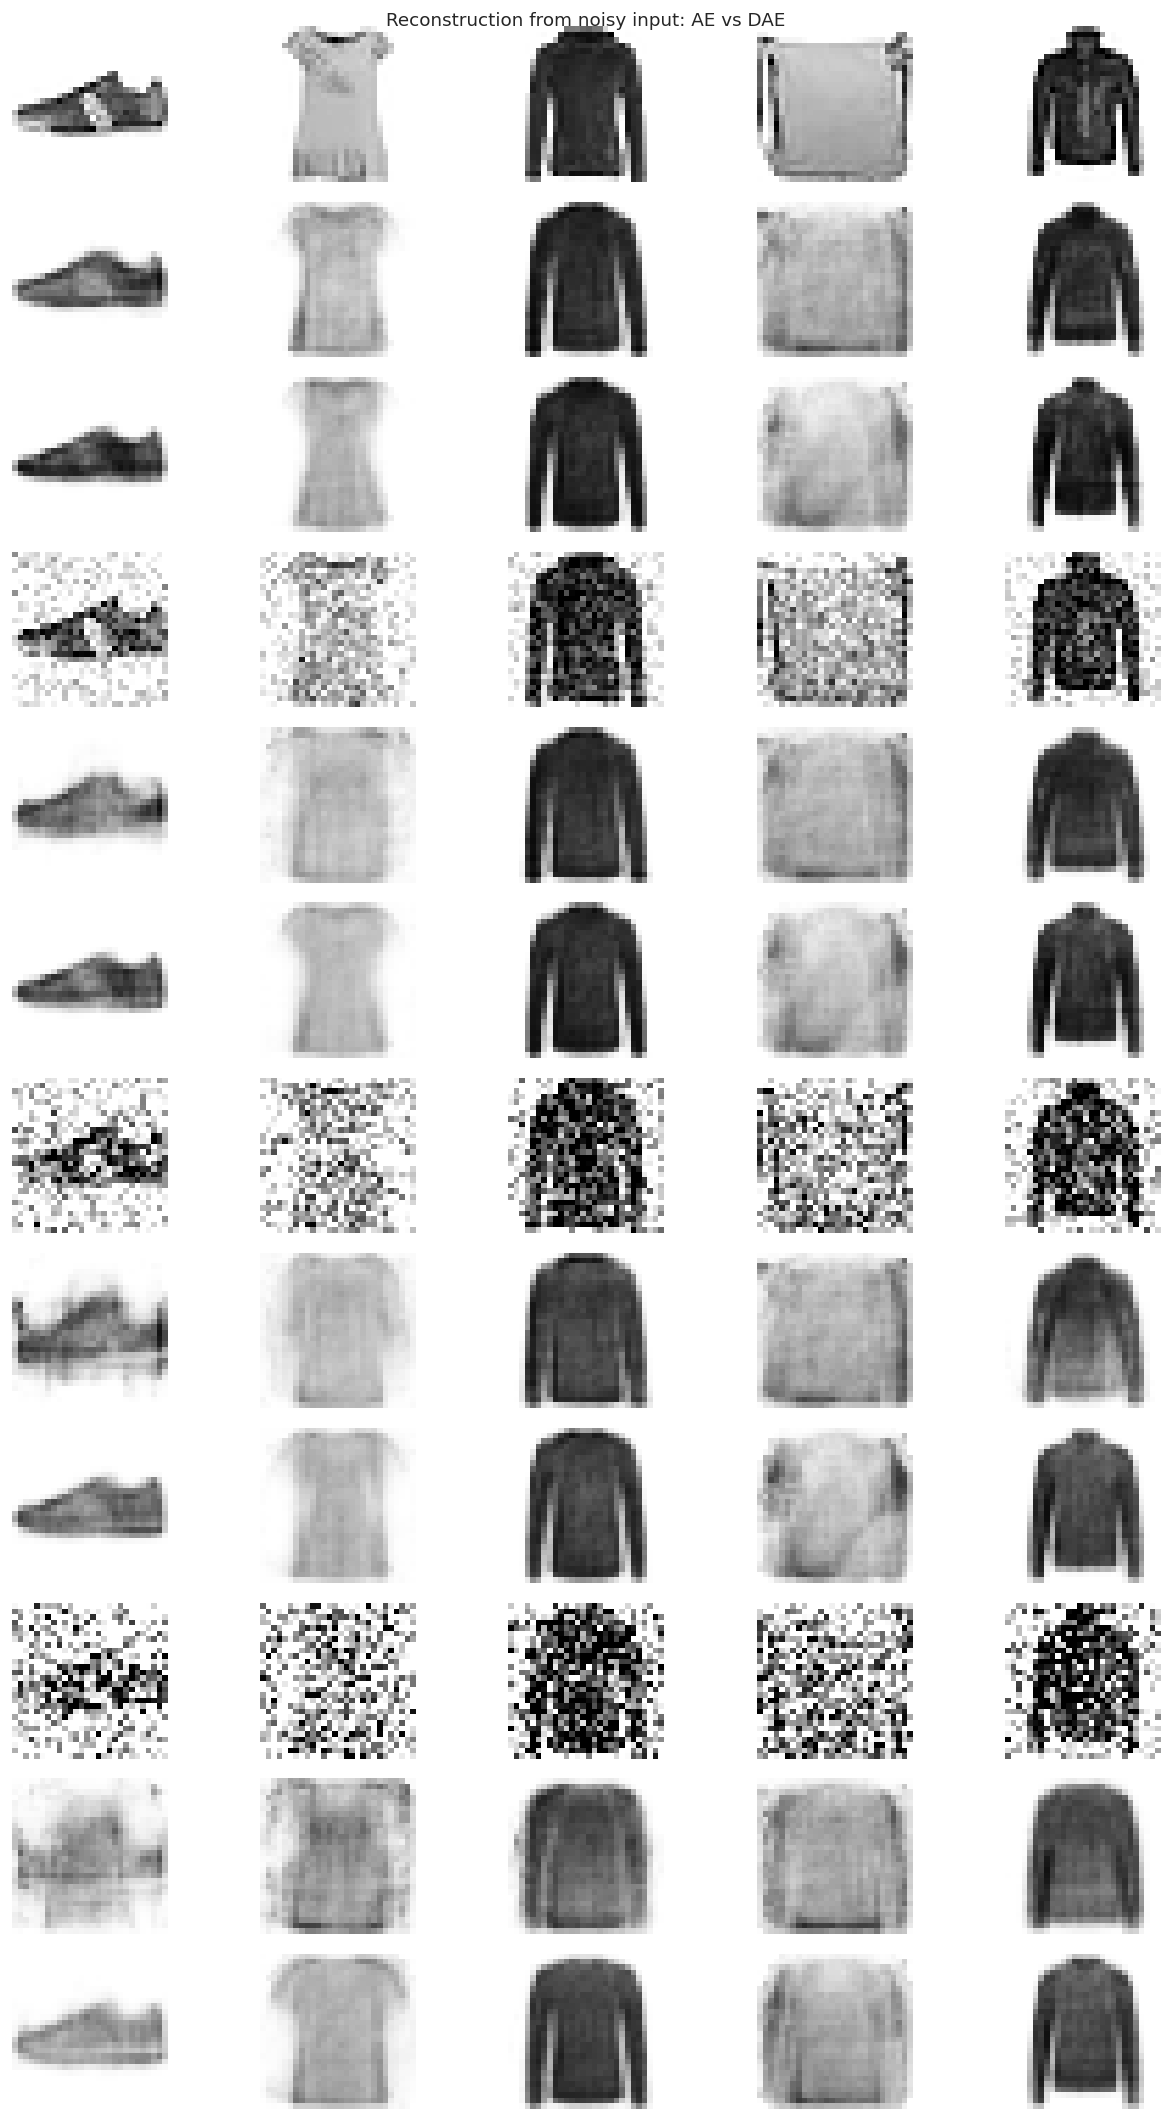

In [14]:
# Compare reconstruction quality at different noise levels
noise_levels = [0.0, 0.15, 0.30, 0.45]
n_show = 5   # samples to display per noise level

rng3 = np.random.RandomState(0)
idxs = rng3.choice(len(X_te), size=n_show, replace=False)
X_clean = X_te[idxs]

fig, axes = plt.subplots(
    len(noise_levels) * 3, n_show,
    figsize=(n_show * 2.2, len(noise_levels) * 4.5),
)

for row_group, sigma in enumerate(noise_levels):
    X_noisy = np.clip(
        X_clean + rng3.randn(*X_clean.shape) * sigma, 0, 1
    ).astype(np.float32)

    model.eval()
    dae_model.eval()
    with torch.no_grad():
        t_noisy  = torch.tensor(X_noisy, dtype=torch.float32)
        ae_recon = model(t_noisy).numpy()
        da_recon = dae_model(t_noisy).numpy()

    r = row_group * 3
    for col in range(n_show):
        for offset, img in enumerate([X_noisy[col], ae_recon[col], da_recon[col]]):
            axes[r + offset, col].imshow(img.reshape(28, 28),
                                         cmap='gray_r', vmin=0, vmax=1)
            axes[r + offset, col].axis('off')
    axes[r,     0].set_ylabel(f'Noisy\n(σ={sigma})', fontsize=7)
    axes[r + 1, 0].set_ylabel('AE',                  fontsize=7)
    axes[r + 2, 0].set_ylabel('DAE',                 fontsize=7)

plt.suptitle('Reconstruction from noisy input: AE vs DAE', fontsize=11)
plt.tight_layout()
plt.show()

In [15]:
# Linear probe: compare AE vs DAE latent representations
def run_probe(h_tr, h_te, y_tr_, y_te_, name):
    clf = LogisticRegression(max_iter=500, random_state=SEED)
    clf.fit(h_tr, y_tr_)
    tr = accuracy_score(y_tr_, clf.predict(h_tr))
    te = accuracy_score(y_te_, clf.predict(h_te))
    print(f'{name:<30}  train: {tr:.1%}   test: {te:.1%}')
    return tr, te

model.eval(); dae_model.eval()
with torch.no_grad():
    Z_ae_tr  = model.encode(torch.tensor(X_tr, dtype=torch.float32)).numpy()
    Z_ae_te  = model.encode(torch.tensor(X_te, dtype=torch.float32)).numpy()
    Z_dae_tr = dae_model.encode(torch.tensor(X_tr, dtype=torch.float32)).numpy()
    Z_dae_te = dae_model.encode(torch.tensor(X_te, dtype=torch.float32)).numpy()

print(f'{"Representation":<30}  {"Train acc":>10}   {"Test acc":>9}')
print('-' * 55)
res_ae  = run_probe(Z_ae_tr,  Z_ae_te,  y_tr, y_te, f'AE  latent z (16D)')
res_dae = run_probe(Z_dae_tr, Z_dae_te, y_tr, y_te, f'DAE latent z (16D)')
run_probe(X_tr, X_te, y_tr, y_te, 'Raw pixels (784D)')

Representation                   Train acc    Test acc
-------------------------------------------------------
AE  latent z (16D)              train: 79.5%   test: 78.8%
DAE latent z (16D)              train: 77.6%   test: 78.0%
Raw pixels (784D)               train: 95.4%   test: 82.2%


(0.95375, 0.8225)

#### Що ми бачимо

**Реконструкція:** при малому шумі (σ=0.15) обидві моделі справляються
добре. При великому (σ=0.45) DAE впевненіше відновлює форму — бо
він бачив шумні зображення під час навчання, а стандартний AE ні.

**Лінійний зонд:** результати на Fashion-MNIST розходяться з патерном
лекції на `digits`.

Сирі пікселі виграють — і значно. Причина: стиснення з 784 до 16 вимірів
відкидає надто багато дискримінативної інформації. На `digits` (64→8)
коефіцієнт стиснення лише 8×; тут він 49× — і це помітно.

DAE при цьому **не перевершує** стандартний AE, на відміну від лекції.
Можливе пояснення: Fashion-MNIST різноманітніший за `digits`, тому
шумова регуляризація з `noise_std=0.2` недостатня, щоб суттєво
вплинути на структуру 16-вимірного коду. Збільшення `latent_dim`
або `noise_std` могло б змінити картину.

---
## 6. Кластеризація та узагальнювальна здатність

### 6.1 Кластеризація в латентному просторі

Застосуємо **KMeans** ($k=10$) безпосередньо до $z$ і виміряємо збіг
із мітками через **Adjusted Rand Index (ARI)**.

### 6.2 Узагальнювальна здатність

Навчимо окремий AE лише на **одязі** (класи 0–4: T-shirt, Trouser, Pullover,
Dress, Coat), а потім закодуємо **взуття та аксесуари** (класи 5–9: Sandal,
Shirt, Sneaker, Bag, Boot), яких модель **ніколи не бачила**.

Якщо латентний простір узагальнюється — нові класи потраплять у
осмислені сусідства (наприклад, Sneaker поруч із Sandal, Coat поруч із Shirt).

ARI on raw pixels  : 0.351
ARI on latent z    : 0.290


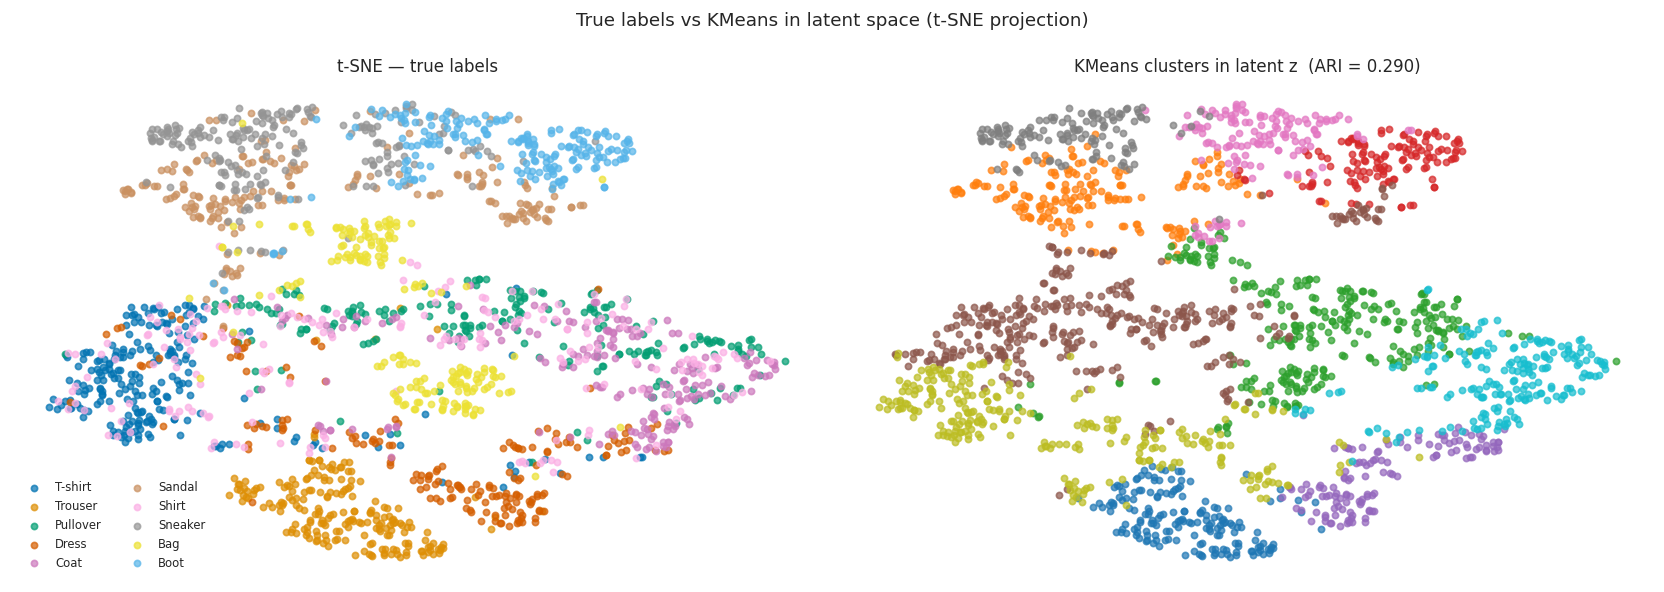

In [16]:
# --- 6.1 Clustering ---
km      = KMeans(n_clusters=10, random_state=SEED, n_init=10)
clust   = km.fit_predict(Z_full)
ari_lat = adjusted_rand_score(y_sub, clust)

km_raw  = KMeans(n_clusters=10, random_state=SEED, n_init=10)
clust_r = km_raw.fit_predict(X_sub)
ari_raw = adjusted_rand_score(y_sub, clust_r)

print(f'ARI on raw pixels  : {ari_raw:.3f}')
print(f'ARI on latent z    : {ari_lat:.3f}')

# Visualise on t-SNE (reuse Y_lat from Part 3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c, col in zip(range(10), COLORS):
    mask = y_2k == c
    axes[0].scatter(Y_lat[mask, 0], Y_lat[mask, 1],
                    color=col, label=CLASS_NAMES[c], s=14, alpha=0.7)
axes[0].set_title('t-SNE — true labels', fontsize=10)
axes[0].axis('off')
axes[0].legend(fontsize=7, ncol=2)

clust_2k = km.predict(Z_2k)
tab10    = plt.cm.tab10(np.linspace(0, 1, 10))
for c in range(10):
    mask = clust_2k == c
    axes[1].scatter(Y_lat[mask, 0], Y_lat[mask, 1],
                    color=tab10[c], label=str(c), s=14, alpha=0.7)
axes[1].set_title(f'KMeans clusters in latent z  (ARI = {ari_lat:.3f})', fontsize=10)
axes[1].axis('off')

plt.suptitle('True labels vs KMeans in latent space (t-SNE projection)', fontsize=11)
plt.tight_layout()
plt.show()

In [17]:
# --- 6.2 Generalisation: train on clothing only (classes 0-4) ---
mask_clothing = y_sub <= 4
X_cloth       = X_sub[mask_clothing]

torch.manual_seed(SEED)
model_cloth = ae.Autoencoder(
    input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM
)
ae.train_autoencoder(
    model_cloth, X_cloth, n_epochs=100, lr=1e-3, batch_size=64, seed=SEED
)
print(f'Trained on {len(X_cloth)} clothing samples (classes 0-4 only).')

Trained on 3000 clothing samples (classes 0-4 only).


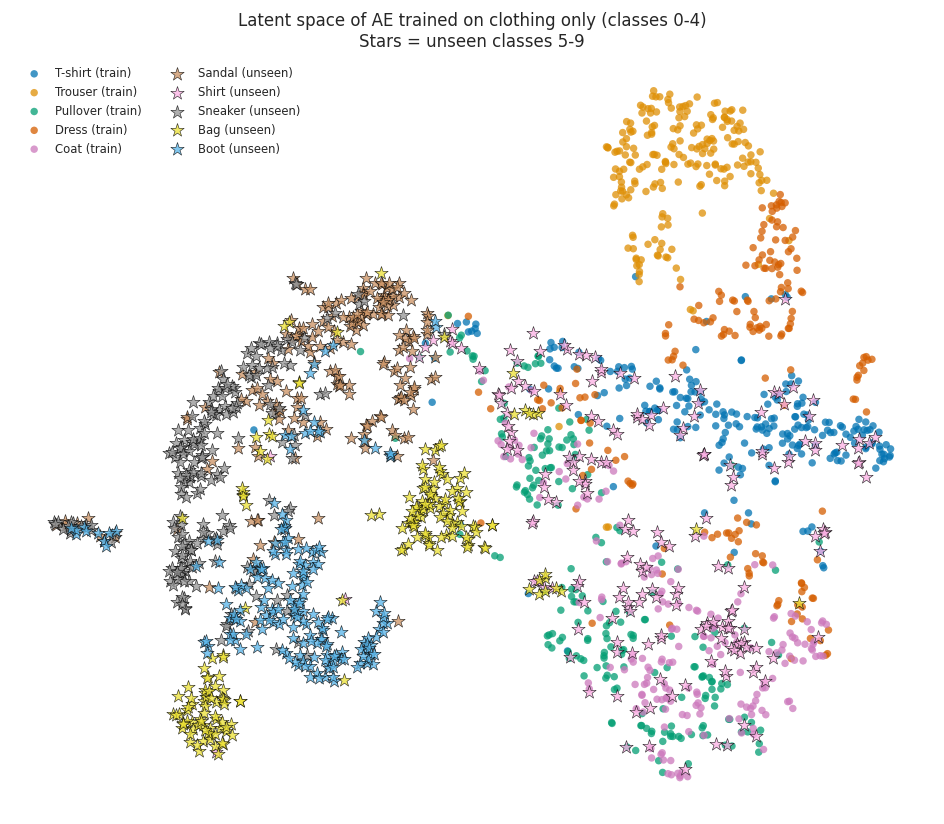

In [18]:
# Encode the full subsample with the clothing-only model
model_cloth.eval()
with torch.no_grad():
    Z_cloth = model_cloth.encode(
        torch.tensor(X_sub, dtype=torch.float32)
    ).numpy()

# t-SNE on these latent codes
idx_gen  = np.random.RandomState(SEED).choice(len(X_sub), size=2000, replace=False)
Y_gen    = TSNE(**tsne_kw).fit_transform(
    StandardScaler().fit_transform(Z_cloth[idx_gen])
)
y_gen    = y_sub[idx_gen]

fig, ax = plt.subplots(figsize=(8, 7))
for c, col in zip(range(10), COLORS):
    mask     = y_gen == c
    is_seen  = c <= 4
    ax.scatter(
        Y_gen[mask, 0], Y_gen[mask, 1],
        color=col,
        s=20 if is_seen else 70,
        alpha=0.75,
        marker='o' if is_seen else '*',
        edgecolors='none' if is_seen else 'black',
        linewidths=0.4,
        label=f'{CLASS_NAMES[c]} (train)' if is_seen
              else f'{CLASS_NAMES[c]} (unseen)',
    )
ax.set_title(
    'Latent space of AE trained on clothing only (classes 0-4)\n'
    'Stars = unseen classes 5-9',
    fontsize=10,
)
ax.axis('off')
ax.legend(fontsize=7, ncol=2, loc='best')
plt.tight_layout()
plt.show()

#### Що ми бачимо

Зверніть на позиції зірочок (класи 5–9) відносно кружечків (0–4).

- **Sneaker / Boot** поруч із **Trouser** або **Coat**?
  Силует взуття з боку схожий на вузький одяг — це підказка декодеру.
- **Bag** в ізольованій зоні?
  Прямокутна форма сумки не схожа ні на що у тренувальних класах.
- **Sandal** поруч із **Shirt / Pullover**?
  Тоді модель «плутає» відкриті структури.

Якщо нові класи утворюють **власні острівці** —
автоенкодер узагальнив візуальну структуру за межі тренувальних міток.

---
## Висновки

| Тема | Ключовий висновок |
|------|------------------|
| **Реалізація** | Encoder / Decoder / Autoencoder / DAE — той самий інтерфейс, що на лекції, але для 784-D входу |
| **Реконструкція** | Fashion-MNIST складніший за digits: деталі текстури втрачаються в 16-D коді |
| **t-SNE vs PCA на $z$** | t-SNE виявляє нелінійну кластерну структуру, недоступну лінійним проекціям |
| **Інтерполяція** | Гладкий перехід між класами свідчить про організований латентний простір; «розмиті коктейлі» — про прогалини між кластерами |
| **DAE** | Шумова регуляризація покращує якість представлення при зашумлених входах і лінійну відокремлюваність |
| **Кластеризація** | KMeans на $z$ дає вищий ARI, ніж на пікселях: стиснення фільтрує нерелевантний пікселевий шум |
| **Узагальнення** | AE організовує простір за візуальною подібністю, тому невидані класи потрапляють у осмислені сусідства |